# Titanic: Who Survived and Why?

**Goal:** explore the passenger data from the sinking of the RMS Titanic, find out which factors were linked to survival, and build a simple machine-learning model that predicts whether a passenger survived.

**Data:** [Kaggle – Titanic: Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic/data) (`train.csv`, 891 passengers).

**Contents**
1. Load and inspect the data
2. Data cleaning
3. Exploratory data analysis (EDA)
4. Feature engineering
5. Modelling
6. Conclusions

## 1. Load and inspect the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/train.csv")
print(f"Rows: {df.shape[0]}, columns: {df.shape[1]}")
df.head()

Rows: 891, columns: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


| Column | Meaning |
|---|---|
| `Survived` | 0 = No, 1 = Yes (**target**) |
| `Pclass` | Ticket class: 1 = 1st, 2 = 2nd, 3 = 3rd |
| `SibSp` | # siblings / spouses aboard |
| `Parch` | # parents / children aboard |
| `Embarked` | Port: C = Cherbourg, Q = Queenstown, S = Southampton |

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing": missing, "percent": missing_pct}).query("missing > 0")

,missing,percent
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


**Observations**
- `Cabin` is missing for ~77% of passengers – too sparse to use directly.
- `Age` is missing for ~20% – worth filling in.
- `Embarked` is missing for only 2 passengers.

## 2. Data cleaning

In [5]:
data = df.copy()

# Title from the name (Mr, Mrs, Miss, Master, ...) – useful for age and survival
data["Title"] = data["Name"].str.extract(r",\s*([^\.]+)\.")
data["Title"] = data["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
rare = data["Title"].value_counts()[lambda s: s < 10].index
data["Title"] = data["Title"].replace(rare, "Rare")

# Fill missing Age with the median age of passengers who share the same title
data["Age"] = data.groupby("Title")["Age"].transform(lambda s: s.fillna(s.median()))

# Fill the 2 missing Embarked values with the most common port
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

# Keep only whether a cabin was recorded
data["HasCabin"] = data["Cabin"].notna().astype(int)

data[["Age", "Embarked", "Title", "HasCabin"]].isna().sum()

Age         0
Embarked    0
Title       0
HasCabin    0
dtype: int64

## 3. Exploratory data analysis

Overall survival rate: 38.4%


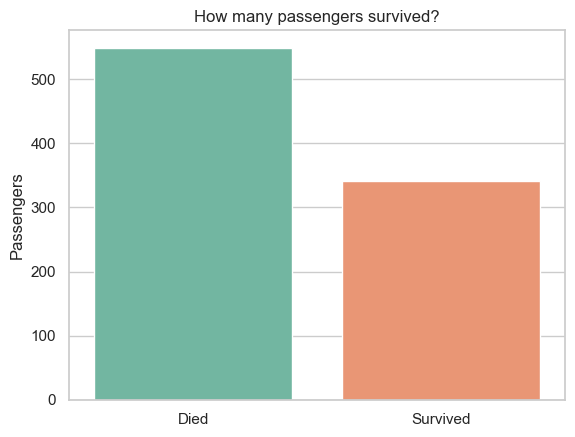

In [6]:
survival_rate = data["Survived"].mean()
print(f"Overall survival rate: {survival_rate:.1%}")

ax = sns.countplot(data=data, x="Survived")
ax.set_xticks([0, 1], ["Died", "Survived"])
ax.set(title="How many passengers survived?", xlabel="", ylabel="Passengers")
plt.show()

### Survival by sex and ticket class

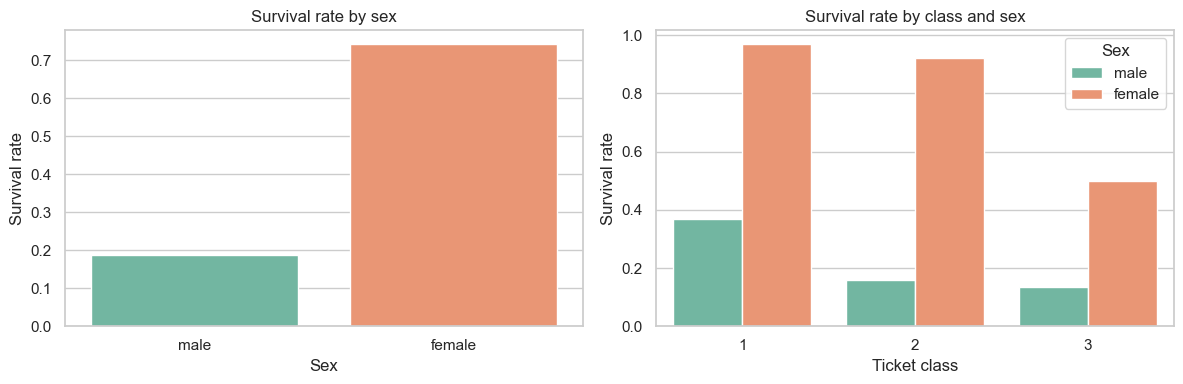

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=data, x="Sex", y="Survived", ax=axes[0], errorbar=None)
axes[0].set(title="Survival rate by sex", ylabel="Survival rate")

sns.barplot(data=data, x="Pclass", y="Survived", hue="Sex", ax=axes[1], errorbar=None)
axes[1].set(title="Survival rate by class and sex", xlabel="Ticket class", ylabel="Survival rate")

plt.tight_layout()
plt.savefig("../images/survival_by_sex_class.png", dpi=120)
plt.show()

In [8]:
pd.crosstab([data["Pclass"], data["Sex"]], data["Survived"], normalize="index").round(2)

Survived          0     1
Pclass Sex               
1      female  0.03  0.97
       male    0.63  0.37
2      female  0.08  0.92
       male    0.84  0.16
3      female  0.50  0.50
       male    0.86  0.14

**"Women and children first"** is clearly visible: about 74% of women survived versus 19% of men.
Class mattered too – almost all women in 1st and 2nd class survived, while only half of 3rd‑class women did.

### Survival by age

/Users/olgakoleda/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


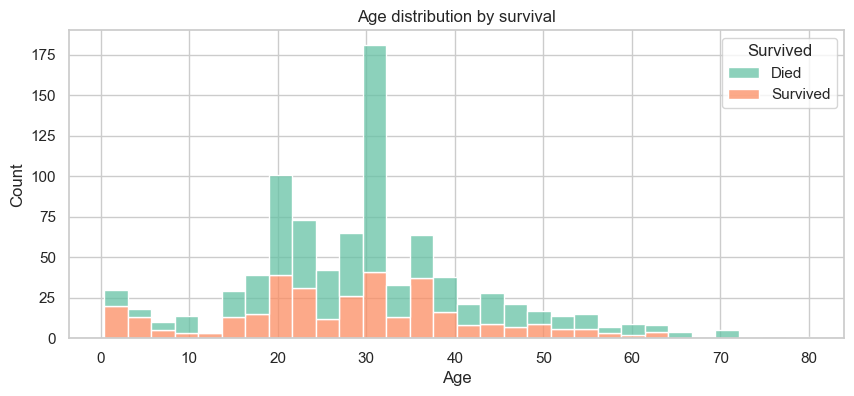

,mean,count
AgeGroup,,
Child,0.58,73
Teen,0.43,70
Young adult,0.35,530
Adult,0.40,196
Senior,0.23,22


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
outcome = data["Survived"].map({0: "Died", 1: "Survived"})
sns.histplot(data=data, x="Age", hue=outcome, bins=30, multiple="stack", ax=ax)
ax.set(title="Age distribution by survival")
plt.show()

data["AgeGroup"] = pd.cut(data["Age"], bins=[0, 12, 18, 35, 60, 80],
                          labels=["Child", "Teen", "Young adult", "Adult", "Senior"])
data.groupby("AgeGroup", observed=True)["Survived"].agg(["mean", "count"]).round(2)

Children (≤12) had the highest survival rate; seniors the lowest.

### Family size and port of embarkation

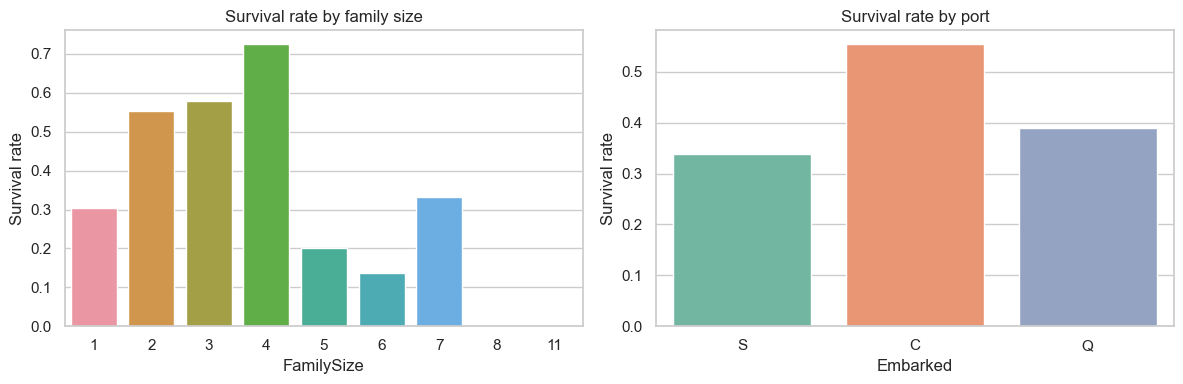

In [10]:
data["FamilySize"] = data["SibSp"] + data["Parch"] + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=data, x="FamilySize", y="Survived", ax=axes[0], errorbar=None)
axes[0].set(title="Survival rate by family size", ylabel="Survival rate")
sns.barplot(data=data, x="Embarked", y="Survived", ax=axes[1], errorbar=None)
axes[1].set(title="Survival rate by port", ylabel="Survival rate")
plt.tight_layout()
plt.show()

Small families (2–4 people) did better than people travelling alone or in very large families.

### Correlation between numeric features

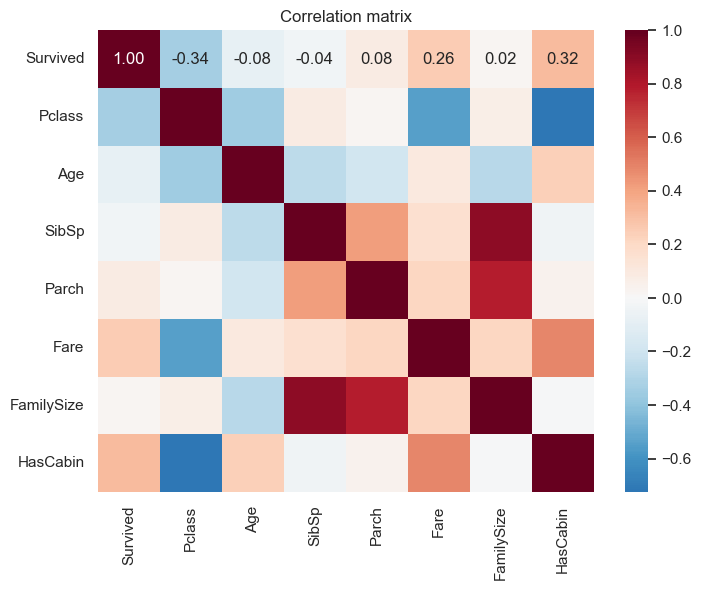

In [11]:
num_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "HasCabin"]
plt.figure(figsize=(8, 6))
sns.heatmap(data[num_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation matrix")
plt.show()

## 4. Feature engineering

In [12]:
features = ["Pclass", "Sex", "Age", "Fare", "FamilySize", "HasCabin", "Embarked", "Title"]

X = pd.get_dummies(data[features], columns=["Sex", "Embarked", "Title"], drop_first=True)
y = data["Survived"]
X.head()

,Pclass,Age,Fare,FamilySize,HasCabin,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,22.0,7.2500,2,0,True,False,True,False,True,False,False
1,1,38.0,71.2833,2,1,False,False,False,False,False,True,False
2,3,26.0,7.9250,1,0,False,False,True,True,False,False,False
3,1,35.0,53.1000,2,1,False,False,True,False,False,True,False
4,3,35.0,8.0500,1,0,True,False,True,False,True,False,False


## 5. Modelling

We compare a simple baseline (predict that every woman survives) with two models, using 5‑fold cross‑validation.

In [13]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

baseline_acc = accuracy_score(y_test, (X_test["Sex_male"] == 0).astype(int))
print(f"Baseline (all women survive): {baseline_acc:.3f}")

models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42),
}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name}: CV accuracy {scores.mean():.3f} ± {scores.std():.3f}")

Baseline (all women survive): 0.777
Logistic Regression: CV accuracy 0.820 ± 0.019
Random Forest: CV accuracy 0.820 ± 0.024


Test accuracy: 0.810

              precision    recall  f1-score   support

        Died       0.82      0.89      0.85       110
    Survived       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



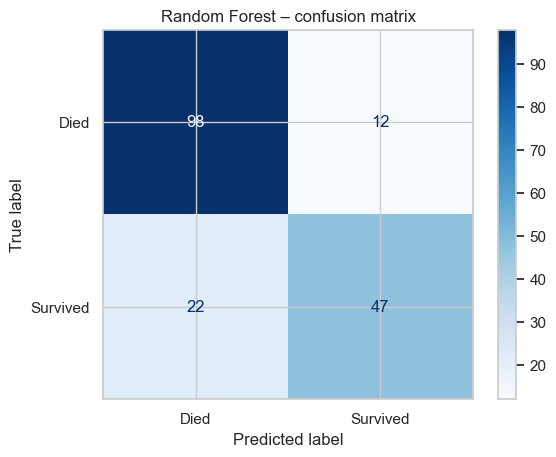

In [14]:
best = models["Random Forest"].fit(X_train, y_train)
pred = best.predict(X_test)

print(f"Test accuracy: {accuracy_score(y_test, pred):.3f}\n")
print(classification_report(y_test, pred, target_names=["Died", "Survived"]))

ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Died", "Survived"], cmap="Blues")
plt.title("Random Forest – confusion matrix")
plt.show()

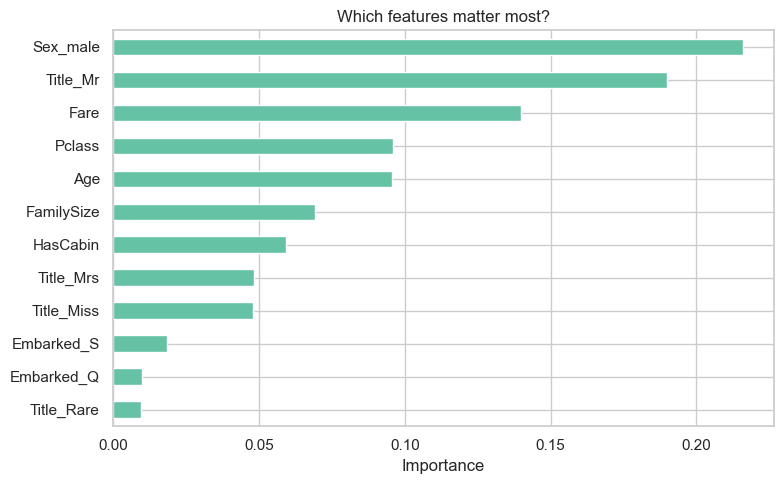

In [15]:
importance = pd.Series(best.feature_importances_, index=X.columns).sort_values()
importance.plot.barh(figsize=(8, 5), title="Which features matter most?")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../images/feature_importance.png", dpi=120)
plt.show()

## 6. Conclusions

- **Sex** was the strongest predictor of survival: women were roughly 4× more likely to survive than men.
- **Ticket class** mattered: 1st‑class passengers survived at about 63%, 3rd‑class at about 24%.
- **Children** and passengers in **small families** had better chances.
- A Random Forest model reaches about **82% cross‑validated accuracy** (81% on the held‑out test set), beating the simple “all women survive” baseline.

**Next steps:** tune hyper‑parameters, try gradient boosting, and submit predictions for `test.csv` to the Kaggle competition.